<a href="https://colab.research.google.com/github/ArifRahmanS070703/UTS_Pembelajaran-Mesin_1217050020_ArifRahmanS/blob/main/UTS_Pembelajaran_Mesin_Arif_Rahman_Sopian_1217005020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


======= Naive Bayes =======
Akurasi: 92.60%

Confusion Matrix:
[[933  67]
 [ 81 919]]

Classification Report:
              precision    recall  f1-score   support

  grapefruit       0.92      0.93      0.93      1000
      orange       0.93      0.92      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



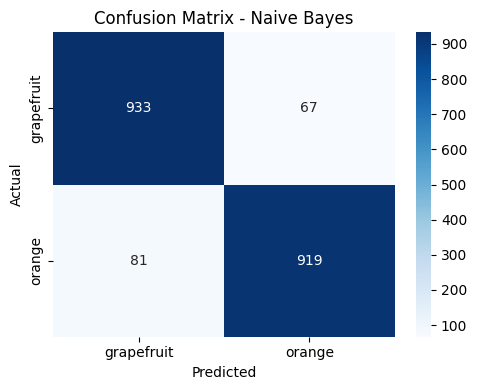


======= Decision Tree =======
Akurasi: 92.10%

Confusion Matrix:
[[936  64]
 [ 94 906]]

Classification Report:
              precision    recall  f1-score   support

  grapefruit       0.91      0.94      0.92      1000
      orange       0.93      0.91      0.92      1000

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



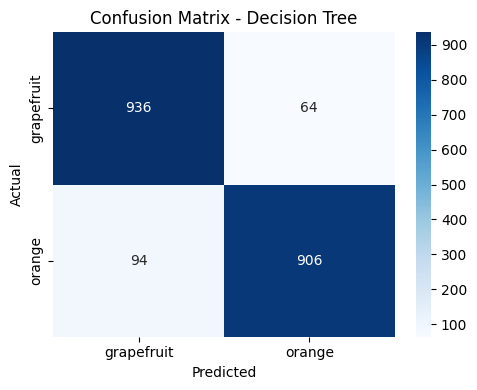


======= SVM =======
Akurasi: 93.95%

Confusion Matrix:
[[948  52]
 [ 69 931]]

Classification Report:
              precision    recall  f1-score   support

  grapefruit       0.93      0.95      0.94      1000
      orange       0.95      0.93      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



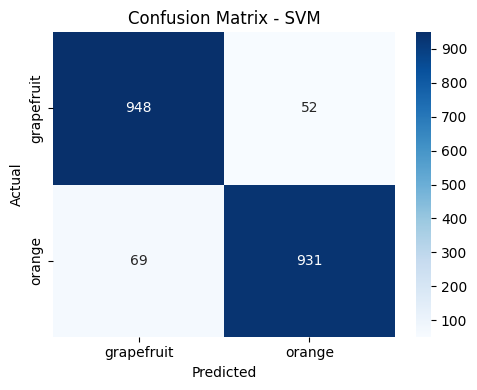

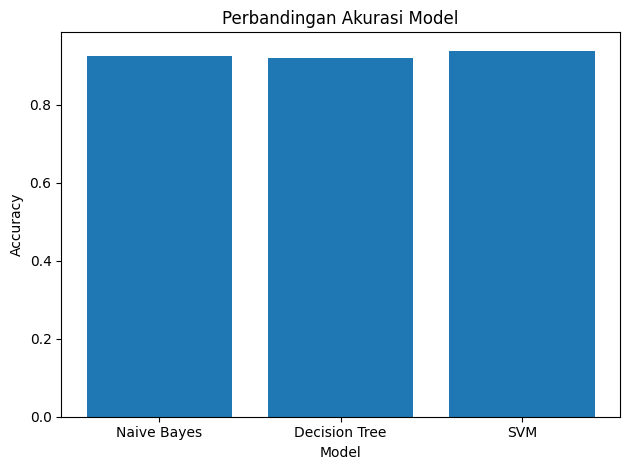


=== Perbandingan Model ===
           Model  Accuracy
0    Naive Bayes    0.9260
1  Decision Tree    0.9210
2            SVM    0.9395


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# =========================================
# 1. Load Dataset
# =========================================
df = pd.read_csv("citrus.csv")

# =========================================
# 2. Pisahkan fitur dan target
# =========================================
X = df.drop('name', axis=1)
y = df['name']

# =========================================
# 3. Encode Label
# =========================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# =========================================
# 4. Split Data (pakai stratify biar seimbang)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# =========================================
# 5. Scaling (khusus SVM)
# =========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================================
# 6. Model Naive Bayes
# =========================================
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# =========================================
# 7. Model Decision Tree
# =========================================
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# =========================================
# 8. Model SVM
# =========================================
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)


# =========================================
# 9. Fungsi Evaluasi
# =========================================
def evaluasi(nama, y_true, y_pred):
    print(f"\n======= {nama} =======")

    acc = accuracy_score(y_true, y_pred)
    print("Akurasi: {:.2f}%".format(acc * 100))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {nama}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return acc


# =========================================
# 10. Evaluasi Semua Model
# =========================================
acc_nb = evaluasi("Naive Bayes", y_test, y_pred_nb)
acc_dt = evaluasi("Decision Tree", y_test, y_pred_dt)
acc_svm = evaluasi("SVM", y_test, y_pred_svm)


# =========================================
# 11. Perbandingan Model (Grafik)
# =========================================
model_names = ["Naive Bayes", "Decision Tree", "SVM"]
accuracies = [acc_nb, acc_dt, acc_svm]

plt.figure()
plt.bar(model_names, accuracies)
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


# =========================================
# 12. Tabel Hasil
# =========================================
hasil = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

print("\n=== Perbandingan Model ===")
print(hasil)

In [1]:
from google.colab import files
uploaded = files.upload()

Saving citrus.csv to citrus.csv


In [2]:
import pandas as pd
df = pd.read_csv("citrus.csv")
df.head()

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9
